# Experimental PXRD inventory — what is actually trainable

Counts the experimental patterns in the `crystalai-data` store (`exp_data/`) and reports,
per source, how many can feed each of the two models:

| Model | Needs | Target |
|---|---|---|
| **Track A — CS/SG classification** | pattern + background + a crystal-system (and space-group) label | 7-way CS, 230-way SG |
| **Track B — CSP (structure prediction)** | pattern + background + **full structure** (lattice *and* atomic basis), **≤ 20 atoms/cell** | the structure itself |

**Scope.** Internal lab (RWTH-A) + RRUFF + opXRD restricted to the **CNRS** and **HKUST-A**
sub-collections. opXRD HKUST-B is excluded here — it ships no phase at all, so it is
unlabelled for both tracks (`DATA_ROADMAP.md` §2).

**Three things drive every number below:**

1. **Background must be defined.** A pattern is only usable once a background-subtracted view
   exists. Lab patterns carry a manually-defined, verified background; RRUFF ships a curated
   `XY_Processed` for part of its dump; everything else (the rest of RRUFF, all of opXRD)
   gets a pybaselines arPLS auto-background at ingest. §2 counts the provenance split and
   *measures* how much background there actually is.
2. **Structure knowledge is tiered, not binary.** Only lab and opXRD carry atomic coordinates.
   RRUFF ships **no atomic positions anywhere** — lattice + SG + formula only — so it is held
   out as its own "cell-only" tier: usable for Track A and for lattice/symmetry supervision,
   never as a CSP target. 161 CNRS phases are cell-only for the same reason (lattice, no basis).
3. **The ≤ 20-atom CSP cut is coordinate-dependent.** opXRD CIFs are stored **P1-expanded**
   (the source JSON ships no symmetry), so their as-stored atom count is an upper bound.
   §5 reports the cut both ways — as-stored cell and primitive-reduced cell.

Nothing here re-derives symmetry: CS/SG are read from the index as ingested.

In [2]:
from __future__ import annotations

import sqlite3
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from crystalai_data.crystals.symmetry import cs_number_to_name, sg_number_to_symbol
from crystalai_data.xrddata import database as xdb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

STORE = xdb.default_store()                     # crystalai-data/exp_data
CRYSTALS_DB = STORE.parent / "crystals.sqlite"  # ICSD + MP-20, for the lab cif_id link
# Derived-from-store artefacts, anchored next to this notebook (cwd-independent).
CACHE = STORE.parent / "notebooks" / "nb_cache"
CACHE.mkdir(exist_ok=True)

# opXRD sub-collections in scope. HKUST-B carries no phase -> out of scope here.
OPXRD_SUBSETS = ("CNRS", "HKUST-A")
CSP_MAX_ATOMS = 20

CS_ORDER = list(range(1, 8))
CS_NAMES = [cs_number_to_name(c) for c in CS_ORDER]

# --- palette (dataviz reference instance; categorical slots in fixed order) ---
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SOURCE_COLOR = {"lab": C_BLUE, "rruff": C_ORANGE, "opxrd": C_AQUA}
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8985", "#e6e5e1"

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK_2, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": GRID, "grid.linewidth": 0.8, "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 9, "lines.linewidth": 2,
})


def bar_ax(ax, *, xgrid=False):
    """Recessive grid on the value axis only."""
    ax.set_axisbelow(True)
    ax.grid(axis="x" if xgrid else "y", linewidth=0.8)
    ax.grid(axis="y" if xgrid else "x", visible=False)
    return ax


print(f"store        {STORE}")
print(f"crystals db  {CRYSTALS_DB}  (exists={CRYSTALS_DB.exists()})")

store        /home_network/sdas/Projects/crystalai-projects/crystalai/crystalai-data/exp_data
crystals db  /home_network/sdas/Projects/crystalai-projects/crystalai/crystalai-data/crystals.sqlite  (exists=True)


## 1. Inventory

One row per pattern in `index.csv`. `subsource` splits opXRD into its collections; lab and
RRUFF are single collections. The scope filter drops opXRD HKUST-B.

In [3]:
idx = xdb.read_index(STORE)
idx["subsource"] = np.where(
    idx.source == "opxrd", idx.source_id.str.split("_").str[1], idx.source
)

IN_SCOPE = ["lab", "rruff", "CNRS", "HKUST-A"]
df = idx[idx["subsource"].isin(IN_SCOPE)].copy()
df["subsource"] = pd.Categorical(df["subsource"], categories=IN_SCOPE, ordered=True)

print(f"index total       {len(idx):,}")
print(f"in scope          {len(df):,}   (dropped {len(idx) - len(df):,}: opXRD HKUST-B, no phase)")
print()

inventory = pd.DataFrame({
    "patterns": df.groupby("subsource", observed=True).size(),
    "wavelength known": df.groupby("subsource", observed=True).wavelength_A.apply(lambda s: s.notna().sum()),
    "CS label": df.groupby("subsource", observed=True).crystal_system.apply(lambda s: s.notna().sum()),
    "SG label": df.groupby("subsource", observed=True).space_group.apply(lambda s: s.notna().sum()),
    "cell (a,b,c,α,β,γ)": df.groupby("subsource", observed=True).a.apply(lambda s: s.notna().sum()),
    "atomic basis (CIF)": df.groupby("subsource", observed=True).apply(
        lambda g: int((g.cif_path.notna() | g.cif_id.notna()).sum())
    ),
    "multi-phase": df.groupby("subsource", observed=True).apply(lambda g: int((g.n_phases > 1).sum())),
})
inventory.loc["TOTAL"] = inventory.sum()
display(inventory)

index total       4,654
in scope          4,155   (dropped 499: opXRD HKUST-B, no phase)



,patterns,wavelength known,CS label,SG label,"cell (a,b,c,α,β,γ)",atomic basis (CIF),multi-phase
subsource,,,,,,,
lab,80,80,80,80,80,80,0
rruff,3002,2766,2920,2638,2921,0,0
CNRS,1052,860,886,886,1052,891,0
HKUST-A,21,21,21,21,21,21,4
TOTAL,4155,3727,3907,3625,4074,992,4


**Wavelength audit** (`audit.py`), which gates wavelength-conditioned (FiLM) training.
Note the lab rows are `null` — the audit pass predates the lab ingest — but all 80 carry an
explicit Cu Kα1 / Mo Kα1 wavelength, so they are treated as `pass` throughout this notebook.

In [4]:
audit = pd.crosstab(df["subsource"], df.audit.fillna("(not audited)"))
audit["TOTAL"] = audit.sum(axis=1)
display(audit)

# Effective wavelength verdict used downstream: lab counts as pass on the strength of its wavelength.
df["wl_ok"] = (df.audit == "pass") | ((df.source == "lab") & df.wavelength_A.notna())
print(f"usable wavelength: {int(df.wl_ok.sum()):,} / {len(df):,}")

audit,(not audited),missing_wavelength,pass,suspicious_wavelength,TOTAL
subsource,,,,,
lab,80,0,0,0,80
rruff,0,236,2766,0,3002
CNRS,0,192,859,1,1052
HKUST-A,0,0,21,0,21


usable wavelength: 3,726 / 4,155


## 2. Background — the gate on using anything at all

Every pattern in scope has a background-subtracted view; what differs is its **provenance**:

* `autobg = 0` — native/curated: the lab's manually-defined verified `y_bkg`, or RRUFF's own
  `XY_Processed`.
* `autobg = 1` — pybaselines arPLS auto-background computed at ingest (validated against RRUFF
  ground truth at ρ ≈ 0.996).

In [5]:
prov = pd.crosstab(df["subsource"], df.autobg.map({0: "native / curated", 1: "auto (arPLS)"}))
for c in ("native / curated", "auto (arPLS)"):
    if c not in prov:
        prov[c] = 0
prov = prov[["native / curated", "auto (arPLS)"]]
prov["no background"] = df.groupby("subsource", observed=True).bgsub_path.apply(lambda s: s.isna().sum())
prov.loc["TOTAL"] = prov.sum()
display(prov)

autobg,native / curated,auto (arPLS),no background
subsource,,,
lab,80,0,0
rruff,1229,1773,0
CNRS,0,1052,0
HKUST-A,0,21,0
TOTAL,1309,2846,0


### How much background is actually there?

For every pattern, background share = `mean(raw − bgsub) / mean(raw)` — the fraction of the
measured signal the background accounts for. This checks the working assumption that the
RRUFF patterns *without* a curated `XY_Processed` are the ones with little background to
begin with (in which case the auto-background is doing almost nothing and is low-risk).

In [6]:
def read_xy(path: Path) -> tuple[np.ndarray, np.ndarray]:
    x, y = np.loadtxt(path, comments="#", unpack=True)
    return np.atleast_1d(x), np.atleast_1d(y)


BG_CACHE = CACHE / "background_share.csv"
if BG_CACHE.exists():
    bg = pd.read_csv(BG_CACHE)
else:
    rows = []
    for r in df.itertuples():
        try:
            xr, yr = read_xy(STORE / r.raw_path)
            xb, yb = read_xy(STORE / r.bgsub_path)
        except Exception:
            continue
        ybi = np.interp(xr, xb, yb)
        denom = float(np.nanmean(yr))
        if not np.isfinite(denom) or denom <= 0:
            continue
        rows.append({"id": int(r.id), "bg_share": float(np.nanmean(yr - ybi) / denom)})
    bg = pd.DataFrame(rows)
    bg.to_csv(BG_CACHE, index=False)

df = df.merge(bg, on="id", how="left")
df["bg_group"] = np.where(
    df.source == "rruff",
    np.where(df.autobg == 0, "RRUFF · curated", "RRUFF · auto"),
    np.where(df.source == "lab", "lab · manual", "opXRD · auto"),
)

# 6 patterns land outside [0, 1] — a raw/processed scaling mismatch in 4 RRUFF
# entries and 2 CNRS ones. Clipped for the buckets; called out rather than hidden.
n_out = int(((df.bg_share < -1e-6) | (df.bg_share > 1)).sum())
df["bg_share_clip"] = df.bg_share.clip(0, 1)

BG_BUCKETS = ["none (0%)", "<10%", "10–30%", "30–60%", ">60%"]
df["bg_bucket"] = pd.cut(df.bg_share_clip, bins=[-1e-9, 1e-6, 0.10, 0.30, 0.60, 1.01],
                         labels=BG_BUCKETS)

GROUPS = ["lab · manual", "RRUFF · curated", "RRUFF · auto", "opXRD · auto"]
bg_stats = pd.DataFrame({
    "n": df.groupby("bg_group").size(),
    "median share": df.groupby("bg_group").bg_share_clip.median().round(3),
    "p90 share": df.groupby("bg_group").bg_share_clip.quantile(0.90).round(3),
    "zero background": df.groupby("bg_group").bg_share_clip.apply(lambda s: int((s <= 1e-6).sum())),
}).reindex(GROUPS)
bg_stats["zero %"] = (100 * bg_stats["zero background"] / bg_stats.n).round(1)
display(bg_stats)
print(f"{n_out} patterns fall outside [0, 1] (raw/processed scaling mismatch) — clipped above.")

,n,median share,p90 share,zero background,zero %
bg_group,,,,,
lab · manual,80,0.815,0.953,0,0.0
RRUFF · curated,1229,0.555,0.822,8,0.7
RRUFF · auto,1773,0.000,0.000,1609,90.8
opXRD · auto,1073,0.758,0.921,2,0.2


6 patterns fall outside [0, 1] (raw/processed scaling mismatch) — clipped above.


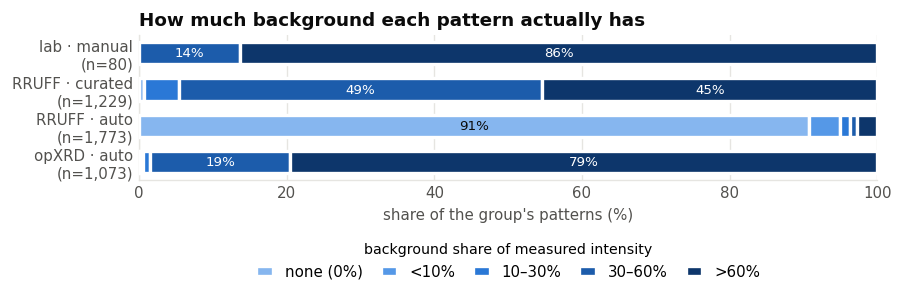

In [7]:
buckets = pd.crosstab(df.bg_group, df.bg_bucket).reindex(GROUPS).reindex(columns=BG_BUCKETS, fill_value=0)
share = 100 * buckets.div(buckets.sum(axis=1), axis=0)

# Sequential blue, light -> dark: more background = darker. Ordinal ramp, so the
# lightest step is 250 (clears 2:1 on a light surface).
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]

fig, ax = plt.subplots(figsize=(7.6, 2.9))
left = np.zeros(len(GROUPS))
ys = np.arange(len(GROUPS))
for bucket, color in zip(BG_BUCKETS, RAMP):
    vals = share[bucket].values
    ax.barh(ys, vals, left=left, height=0.62, color=color, edgecolor="white",
            linewidth=2, label=bucket, zorder=3)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v >= 7:
            ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                    color="white" if color in RAMP[2:] else INK)
    left += vals
ax.set_yticks(ys, [f"{g}\n(n={buckets.loc[g].sum():,})" for g in GROUPS])
ax.set_xlim(0, 100)
ax.set_xlabel("share of the group's patterns (%)")
ax.set_title("How much background each pattern actually has")
ax.invert_yaxis()
bar_ax(ax, xgrid=True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.34), ncols=5, columnspacing=1.2,
          handlelength=1.1, title="background share of measured intensity",
          title_fontsize=8.5)
plt.tight_layout()
plt.show()

**This confirms the working assumption.** The great majority of the RRUFF patterns that ship
no curated `XY_Processed` have *zero* background — arPLS finds nothing to subtract because
the raw profile is already flat-based. The auto-background is therefore near-inert exactly
where it is applied to RRUFF, and does real work only on opXRD, where essentially every
pattern carries a substantial background, comparable in magnitude to the lab's
manually-defined ones.

## 3. Structure-knowledge tiers

What each pattern actually carries decides which model it can serve:

* **full structure** — lattice *and* atomic basis. Lab rows link to a verified ICSD phase in
  `crystals.sqlite` via `cif_id`; opXRD rows carry their own `structure.cif`. CSP-eligible.
* **cell only** — lattice (± SG/formula), no atomic positions. All of RRUFF and 161 CNRS
  phases. Track-A-eligible, never a CSP target.
* **labels only / none** — no cell.

In [8]:
def tier(r) -> str:
    if pd.notna(r.cif_id) or pd.notna(r.cif_path):
        return "full structure"
    if pd.notna(r.a):
        return "cell only"
    if pd.notna(r.crystal_system):
        return "CS/SG only"
    return "unlabelled"


df["tier"] = df.apply(tier, axis=1)
TIERS = ["full structure", "cell only", "CS/SG only", "unlabelled"]
tiers = pd.crosstab(df["subsource"], df["tier"]).reindex(columns=TIERS, fill_value=0)
tiers["TOTAL"] = tiers.sum(axis=1)
tiers.loc["TOTAL"] = tiers.sum()
display(tiers)

tier,full structure,cell only,CS/SG only,unlabelled,TOTAL
subsource,,,,,
lab,80,0,0,0,80
rruff,0,2921,0,81,3002
CNRS,891,161,0,0,1052
HKUST-A,21,0,0,0,21
TOTAL,992,3082,0,81,4155


## 4. Track A cohort — CS / SG classification

Eligibility funnel, applied in order: in scope → background defined → wavelength usable →
CS label present → SG label present.

In [9]:
steps = {
    "in scope": pd.Series(True, index=df.index),
    "+ background defined": df.bgsub_path.notna(),
    "+ wavelength usable": df.wl_ok,
    "+ CS label": df.crystal_system.notna(),
    "+ SG label": df.space_group.notna(),
}
mask = pd.Series(True, index=df.index)
funnel = {}
for name, cond in steps.items():
    mask &= cond
    funnel[name] = df[mask].groupby("subsource", observed=True).size()
funnel_a = pd.DataFrame(funnel).T.fillna(0).astype(int)
funnel_a["TOTAL"] = funnel_a.sum(axis=1)
display(funnel_a)

track_a_cs = df[df.bgsub_path.notna() & df.wl_ok & df.crystal_system.notna()].copy()
track_a_sg = track_a_cs[track_a_cs.space_group.notna()].copy()
print(f"\nTrack A — CS cohort: {len(track_a_cs):,} patterns")
print(f"Track A — SG cohort: {len(track_a_sg):,} patterns "
      f"({len(track_a_cs) - len(track_a_sg):,} have a CS but no SG — all RRUFF)")

subsource,lab,rruff,CNRS,HKUST-A,TOTAL
in scope,80,3002,1052,21,4155
+ background defined,80,3002,1052,21,4155
+ wavelength usable,80,2766,859,21,3726
+ CS label,80,2766,854,21,3721
+ SG label,80,2615,854,21,3570



Track A — CS cohort: 3,721 patterns
Track A — SG cohort: 3,570 patterns (151 have a CS but no SG — all RRUFF)


In [10]:
def cs_table(sub: pd.DataFrame, label: str) -> pd.DataFrame:
    counts = sub.crystal_system.astype(int).value_counts().reindex(CS_ORDER, fill_value=0)
    out = pd.DataFrame({"crystal system": CS_NAMES, label: counts.values,
                        "share %": (100 * counts / counts.sum()).round(1).values})
    return out.set_index("crystal system")


def imbalance(counts: np.ndarray) -> str:
    p = counts / counts.sum()
    nz = p[p > 0]
    h = float(-(nz * np.log(nz)).sum() / np.log(len(counts)))
    return (f"n={counts.sum():,} | largest={counts.max():,} ({100 * counts.max() / counts.sum():.0f}%) "
            f"| smallest={counts.min():,} | max/min={counts.max() / max(counts.min(), 1):.1f}× "
            f"| normalized entropy={h:.3f}")


cs_a = cs_table(track_a_cs, "patterns")
display(cs_a)
print(imbalance(cs_a["patterns"].values))

,patterns,share %
crystal system,,
triclinic,345,9.3
monoclinic,1157,31.1
orthorhombic,831,22.3
tetragonal,332,8.9
trigonal,402,10.8
hexagonal,229,6.2
cubic,425,11.4


n=3,721 | largest=1,157 (31%) | smallest=229 | max/min=5.1× | normalized entropy=0.922


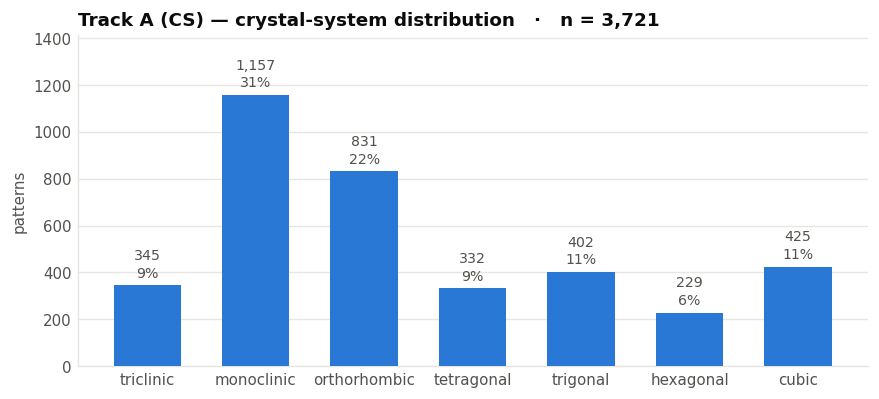

In [11]:
counts = cs_a["patterns"].values
fig, ax = plt.subplots(figsize=(7.4, 3.4))
bars = ax.bar(CS_NAMES, counts, color=C_BLUE, width=0.62, zorder=3)
for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, v + counts.max() * 0.02,
            f"{v:,}\n{100 * v / counts.sum():.0f}%", ha="center", va="bottom",
            fontsize=8.5, color=INK_2, linespacing=1.3)
ax.set_ylim(0, counts.max() * 1.22)
ax.set_ylabel("patterns")
ax.set_title(f"Track A (CS) — crystal-system distribution   ·   n = {counts.sum():,}")
bar_ax(ax)
plt.tight_layout()
plt.show()

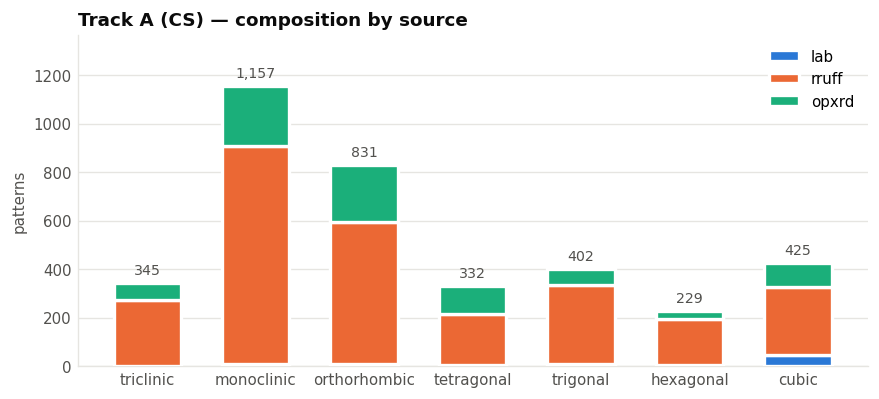

In [12]:
by_src = (track_a_cs.assign(cs=track_a_cs.crystal_system.astype(int))
          .pivot_table(index="cs", columns="source", values="id", aggfunc="count")
          .reindex(CS_ORDER, fill_value=0).fillna(0))
by_src = by_src.reindex(columns=[c for c in ("lab", "rruff", "opxrd") if c in by_src])

fig, ax = plt.subplots(figsize=(7.4, 3.4))
bottom = np.zeros(len(CS_ORDER))
for src in by_src.columns:
    vals = by_src[src].values
    ax.bar(CS_NAMES, vals, bottom=bottom, width=0.62, label=src,
           color=SOURCE_COLOR[src], edgecolor="white", linewidth=2, zorder=3)
    bottom += vals
for x, tot in enumerate(bottom):
    ax.text(x, tot + bottom.max() * 0.02, f"{int(tot):,}", ha="center", va="bottom",
            fontsize=8.5, color=INK_2)
ax.set_ylim(0, bottom.max() * 1.18)
ax.set_ylabel("patterns")
ax.set_title("Track A (CS) — composition by source")
ax.legend(loc="upper right")
bar_ax(ax)
plt.tight_layout()
plt.show()

### Space-group coverage

distinct space groups present : 155 / 230
SGs with ≥ 10 patterns        : 60
SGs with ≥ 50 patterns        : 15
median patterns per present SG: 6
top-10 SGs cover              : 53% of the cohort


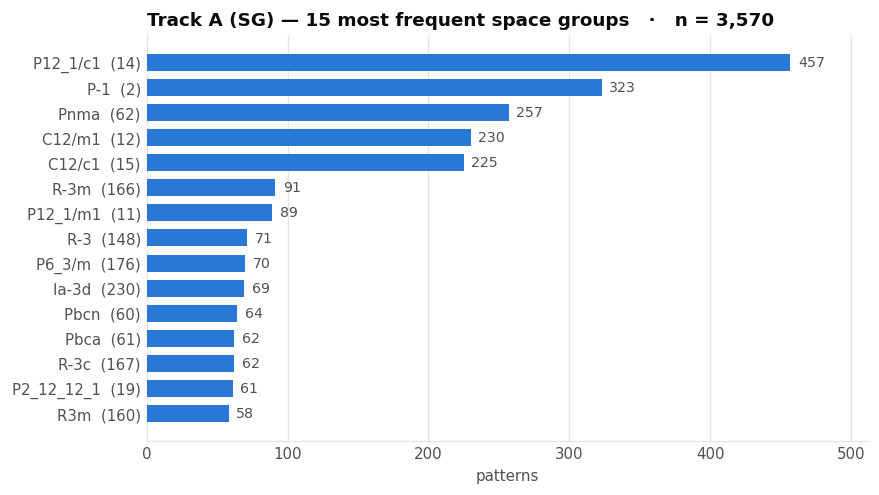

In [13]:
sg_counts = track_a_sg.space_group.astype(int).value_counts()
print(f"distinct space groups present : {sg_counts.size} / 230")
print(f"SGs with ≥ 10 patterns        : {int((sg_counts >= 10).sum())}")
print(f"SGs with ≥ 50 patterns        : {int((sg_counts >= 50).sum())}")
print(f"median patterns per present SG: {sg_counts.median():.0f}")
print(f"top-10 SGs cover              : {100 * sg_counts.nlargest(10).sum() / sg_counts.sum():.0f}% of the cohort")

top = sg_counts.nlargest(15).sort_values()
labels = [f"{sg_number_to_symbol(int(sg))}  ({int(sg)})" for sg in top.index]

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.barh(labels, top.values, color=C_BLUE, height=0.68, zorder=3)
for y, v in enumerate(top.values):
    ax.text(v + top.max() * 0.012, y, f"{v:,}", va="center", fontsize=8.5, color=INK_2)
ax.set_xlim(0, top.max() * 1.12)
ax.set_xlabel("patterns")
ax.set_title(f"Track A (SG) — 15 most frequent space groups   ·   n = {len(track_a_sg):,}")
bar_ax(ax, xgrid=True)
plt.tight_layout()
plt.show()

## 5. CSP cohort — structure prediction, ≤ 20 atoms

Only the **full structure** tier can be a CSP target. Atom counts come from two places:

* **lab** — the linked ICSD entry's `n_atoms` in `crystals.sqlite` (as-parsed cell).
* **opXRD** — parsed from the stored `structure.cif`. These are **P1-expanded**, so the
  as-stored count is an upper bound; the primitive-reduced count (pure pymatgen lattice
  reduction, no spglib) is reported alongside it.

Multi-phase patterns are excluded — they break the one-pattern-one-structure assumption.

In [14]:
# --- lab: atom counts via the ICSD link ---
lab = df[df.source == "lab"].copy()
with sqlite3.connect(CRYSTALS_DB) as con:
    ids = ",".join(str(int(v)) for v in lab.cif_id.dropna().unique())
    xtl = pd.read_sql_query(
        f"SELECT id AS cif_id, n_atoms, n_sites, is_disordered, source AS crystal_source "
        f"FROM crystals WHERE id IN ({ids})", con)
lab = lab.merge(xtl, on="cif_id", how="left")
lab["n_atoms_cell"] = lab.n_atoms
lab["n_atoms_primitive"] = lab.n_atoms  # ICSD cells are stored as-parsed; not re-reduced
print(f"lab patterns linked to an ICSD phase: {int(lab.n_atoms.notna().sum())}/{len(lab)} "
      f"({lab.cif_id.nunique()} distinct ICSD structures)")

lab patterns linked to an ICSD phase: 80/80 (58 distinct ICSD structures)


In [15]:
# --- opXRD: atom counts parsed from the stored CIFs (cached; ~3 min cold) ---
from pymatgen.io.cif import CifParser

OPX_CACHE = CACHE / "opxrd_atom_counts.csv"
PRIM_LIMIT = 1000  # above this a P1 cell cannot reduce to <=20 (centering removes at most 4x)

opx = df[(df.source == "opxrd") & df.cif_path.notna()].copy()
if OPX_CACHE.exists():
    counts_opx = pd.read_csv(OPX_CACHE)
else:
    recs = []
    for r in opx.itertuples():
        structs = CifParser(STORE / r.cif_path).parse_structures(primitive=False)
        n = [int(round(s.composition.element_composition.num_atoms)) for s in structs]
        prim = (int(round(structs[0].get_primitive_structure()
                          .composition.element_composition.num_atoms))
                if n[0] <= PRIM_LIMIT else n[0])
        recs.append(dict(id=int(r.id), n_atoms_cell=n[0], n_atoms_primitive=prim,
                         n_sites=len(structs[0]), is_disordered=int(not structs[0].is_ordered),
                         n_blocks=len(structs), n_atoms_all_phases=int(sum(n))))
    counts_opx = pd.DataFrame(recs)
    counts_opx.to_csv(OPX_CACHE, index=False)

opx = opx.merge(counts_opx, on="id", how="left")
print(f"opXRD CIFs parsed: {len(opx):,}   (P1-expanded cells)")

opXRD CIFs parsed: 912   (P1-expanded cells)


In [16]:
struct = pd.concat([
    lab[["id", "source", "subsource", "crystal_system", "space_group", "n_phases",
         "bgsub_path", "wl_ok", "n_atoms_cell", "n_atoms_primitive"]],
    opx[["id", "source", "subsource", "crystal_system", "space_group", "n_phases",
         "bgsub_path", "wl_ok", "n_atoms_cell", "n_atoms_primitive"]],
], ignore_index=True)

csp_steps = {
    "full structure": pd.Series(True, index=struct.index),
    "+ background defined": struct.bgsub_path.notna(),
    "+ wavelength usable": struct.wl_ok,
    "+ single phase": struct.n_phases == 1,
    f"+ ≤{CSP_MAX_ATOMS} atoms (as-stored cell)": struct.n_atoms_cell <= CSP_MAX_ATOMS,
}
mask = pd.Series(True, index=struct.index)
funnel = {}
for name, cond in csp_steps.items():
    mask &= cond
    funnel[name] = struct[mask].groupby("subsource", observed=True).size()
funnel_b = pd.DataFrame(funnel).T.fillna(0).astype(int)

pre_cut = struct[struct.bgsub_path.notna() & struct.wl_ok & (struct.n_phases == 1)]
funnel_b.loc[f"+ ≤{CSP_MAX_ATOMS} atoms (primitive cell)"] = (
    pre_cut[pre_cut.n_atoms_primitive <= CSP_MAX_ATOMS]
    .groupby("subsource", observed=True).size().reindex(funnel_b.columns, fill_value=0)
)
funnel_b["TOTAL"] = funnel_b.sum(axis=1)
display(funnel_b)

csp = pre_cut[pre_cut.n_atoms_cell <= CSP_MAX_ATOMS].copy()
csp_prim = pre_cut[pre_cut.n_atoms_primitive <= CSP_MAX_ATOMS].copy()
print(f"\nCSP cohort (as-stored cell) : {len(csp):,} patterns")
print(f"CSP cohort (primitive cell) : {len(csp_prim):,} patterns")

subsource,lab,CNRS,HKUST-A,TOTAL
full structure,80,891,21,992
+ background defined,80,891,21,992
+ wavelength usable,80,859,21,960
+ single phase,80,859,17,956
+ ≤20 atoms (as-stored cell),66,150,12,228
+ ≤20 atoms (primitive cell),66,210,13,289



CSP cohort (as-stored cell) : 228 patterns
CSP cohort (primitive cell) : 289 patterns


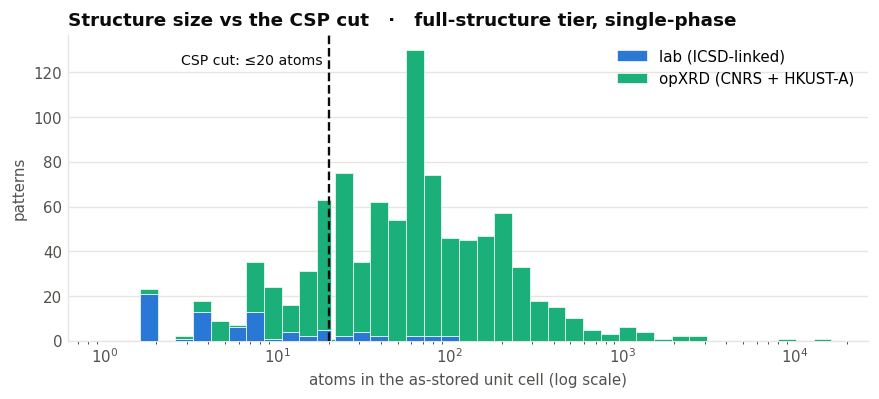

In [17]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
bins = np.logspace(0, np.log10(max(pre_cut.n_atoms_cell.max(), 21)), 42)
bins = np.unique(np.concatenate([bins, [CSP_MAX_ATOMS + 0.5]]))  # an edge exactly on the cut
bottom_hist = np.zeros(len(bins) - 1)
for src, lbl in (("lab", "lab (ICSD-linked)"), ("opxrd", "opXRD (CNRS + HKUST-A)")):
    vals = pre_cut.loc[pre_cut.source == src, "n_atoms_cell"].dropna().values
    h, _ = np.histogram(vals, bins=bins)
    ax.bar(bins[:-1], h, width=np.diff(bins), bottom=bottom_hist, align="edge",
           color=SOURCE_COLOR[src], edgecolor="white", linewidth=0.4, label=lbl, zorder=3)
    bottom_hist += h
ax.axvline(CSP_MAX_ATOMS, color=INK, linewidth=1.4, linestyle="--", zorder=4)
ax.text(CSP_MAX_ATOMS * 0.92, ax.get_ylim()[1] * 0.94, f"CSP cut: ≤{CSP_MAX_ATOMS} atoms",
        ha="right", va="top", fontsize=8.5, color=INK)
ax.set_xscale("log")
ax.set_xlabel("atoms in the as-stored unit cell (log scale)")
ax.set_ylabel("patterns")
ax.set_title("Structure size vs the CSP cut   ·   full-structure tier, single-phase")
ax.legend(loc="upper right")
bar_ax(ax)
plt.tight_layout()
plt.show()

,patterns,share %
crystal system,,
triclinic,3,1.3
monoclinic,37,16.6
orthorhombic,42,18.8
tetragonal,43,19.3
trigonal,23,10.3
hexagonal,10,4.5
cubic,65,29.1


5 of the 228 CSP-eligible patterns carry a structure but no CS/SG label in the index, and are excluded from this table.
n=223 | largest=65 (29%) | smallest=3 | max/min=21.7× | normalized entropy=0.884


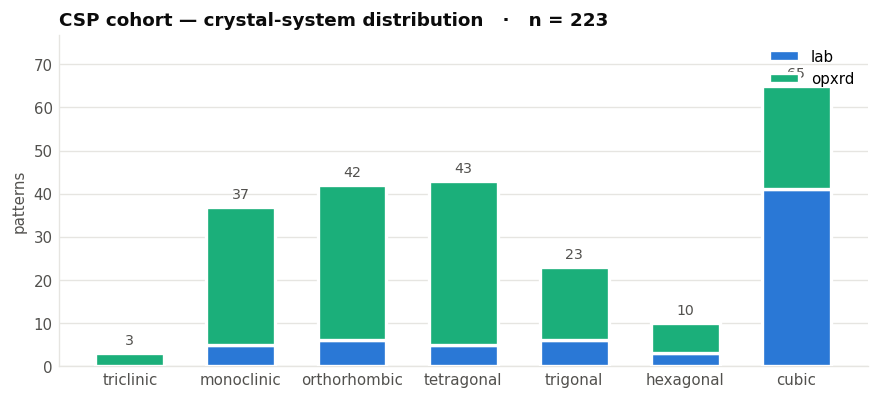

In [18]:
cs_b = cs_table(csp[csp.crystal_system.notna()], "patterns")
display(cs_b)
print(f"{int(csp.crystal_system.isna().sum())} of the {len(csp):,} CSP-eligible patterns carry a "
      f"structure but no CS/SG label in the index, and are excluded from this table.")
print(imbalance(cs_b["patterns"].values))

by_src_b = (csp[csp.crystal_system.notna()].assign(cs=csp.crystal_system.dropna().astype(int))
            .pivot_table(index="cs", columns="source", values="id", aggfunc="count")
            .reindex(CS_ORDER, fill_value=0).fillna(0))
by_src_b = by_src_b.reindex(columns=[c for c in ("lab", "opxrd") if c in by_src_b])

fig, ax = plt.subplots(figsize=(7.4, 3.4))
bottom = np.zeros(len(CS_ORDER))
for src in by_src_b.columns:
    vals = by_src_b[src].values
    ax.bar(CS_NAMES, vals, bottom=bottom, width=0.62, label=src,
           color=SOURCE_COLOR[src], edgecolor="white", linewidth=2, zorder=3)
    bottom += vals
for x, tot in enumerate(bottom):
    ax.text(x, tot + bottom.max() * 0.02, f"{int(tot):,}", ha="center", va="bottom",
            fontsize=8.5, color=INK_2)
ax.set_ylim(0, bottom.max() * 1.18)
ax.set_ylabel("patterns")
ax.set_title(f"CSP cohort — crystal-system distribution   ·   n = {int(bottom.sum()):,}")
ax.legend(loc="upper right")
bar_ax(ax)
plt.tight_layout()
plt.show()

### The RRUFF case — lattice known, structure not

RRUFF ships no atomic coordinates anywhere in the dump: the DIF file gives wavelength, an
H-M space-group symbol, a refined cell and a 2θ peak list, and nothing else. These patterns
can never be a CSP target, but they are the largest block of cell + symmetry supervision in
the store, and the ≤20-atom cut is undefined for them. The 161 CNRS phases with a lattice
but no basis sit in the same bucket.

In [19]:
cell_only_all = df[df.tier == "cell only"].copy()
cell_only = cell_only_all[cell_only_all.bgsub_path.notna() & cell_only_all.wl_ok].copy()
lattice = pd.DataFrame({
    "cell-only patterns": cell_only_all.groupby("subsource", observed=True).size(),
    "after wavelength gate": cell_only.groupby("subsource", observed=True).size(),
    "with CS": cell_only.groupby("subsource", observed=True).crystal_system.apply(lambda s: s.notna().sum()),
    "with SG": cell_only.groupby("subsource", observed=True).space_group.apply(lambda s: s.notna().sum()),
    "with formula": cell_only.groupby("subsource", observed=True).formula.apply(lambda s: s.notna().sum()),
}).fillna(0).astype(int)
lattice = lattice[lattice["cell-only patterns"] > 0]
lattice.loc["TOTAL"] = lattice.sum()
display(lattice)
print("The 161 cell-only CNRS phases are *exactly* the CNRS rows with no wavelength "
      "(audit='missing_wavelength'), so the wavelength gate removes all of them: after it, "
      "the cell-only tier is entirely RRUFF.")

cs_cell = cs_table(cell_only[cell_only.crystal_system.notna()], "patterns")
display(cs_cell)
print(imbalance(cs_cell["patterns"].values))

,cell-only patterns,after wavelength gate,with CS,with SG,with formula
subsource,,,,,
rruff,2921,2766,2766,2615,2753
CNRS,161,0,0,0,0
TOTAL,3082,2766,2766,2615,2753


The 161 cell-only CNRS phases are *exactly* the CNRS rows with no wavelength (audit='missing_wavelength'), so the wavelength gate removes all of them: after it, the cell-only tier is entirely RRUFF.


,patterns,share %
crystal system,,
triclinic,275,9.9
monoclinic,898,32.5
orthorhombic,584,21.1
tetragonal,211,7.6
trigonal,324,11.7
hexagonal,191,6.9
cubic,283,10.2


n=2,766 | largest=898 (32%) | smallest=191 | max/min=4.7× | normalized entropy=0.919


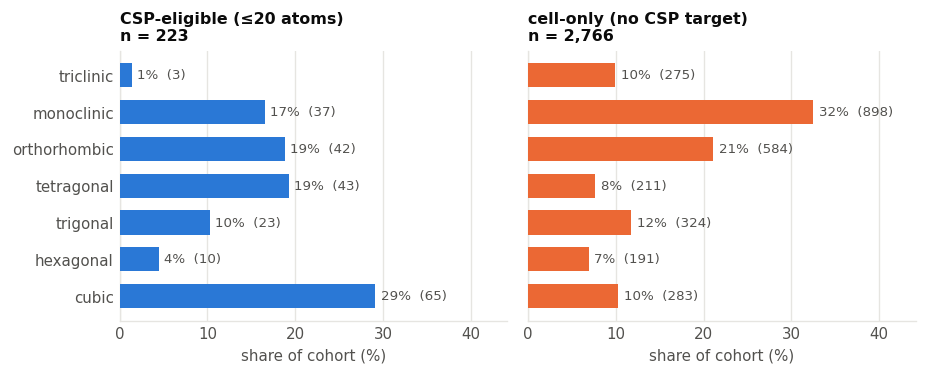

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.2), sharex=True)
panels = [(cs_b, f"CSP-eligible (\u2264{CSP_MAX_ATOMS} atoms)", C_BLUE),
          (cs_cell, "cell-only (no CSP target)", C_ORANGE)]
xmax = max(100 * t["patterns"].max() / max(t["patterns"].sum(), 1) for t, _, _ in panels)
for ax, (tbl, title, color) in zip(axes, [
    (cs_b, f"CSP-eligible (≤{CSP_MAX_ATOMS} atoms)", C_BLUE),
    (cs_cell, "cell-only (no CSP target)", C_ORANGE),
]):
    vals = tbl["patterns"].values
    share = 100 * vals / max(vals.sum(), 1)
    ax.barh(CS_NAMES[::-1], share[::-1], color=color, height=0.66, zorder=3)
    for y, (s, v) in enumerate(zip(share[::-1], vals[::-1])):
        ax.text(s + share.max() * 0.02, y, f"{s:.0f}%  ({v:,})", va="center", fontsize=8, color=INK_2)
    ax.set_xlim(0, xmax * 1.36)
    ax.set_xlabel("share of cohort (%)")
    ax.set_title(f"{title}\nn = {vals.sum():,}", fontsize=9.5)
    bar_ax(ax, xgrid=True)
axes[1].set_yticklabels([])
plt.tight_layout()
plt.show()

## 6. Summary

In [21]:
summary = pd.DataFrame([
    ("in scope (lab + RRUFF + opXRD CNRS/HKUST-A)", len(df)),
    ("  background defined", int(df.bgsub_path.notna().sum())),
    ("    of which curated / manual", int((df.autobg == 0).sum())),
    ("    of which auto (arPLS)", int((df.autobg == 1).sum())),
    ("  usable wavelength", int(df.wl_ok.sum())),
    ("Track A — CS cohort", len(track_a_cs)),
    ("Track A — SG cohort", len(track_a_sg)),
    ("full structure (lattice + basis), single-phase", len(pre_cut)),
    (f"CSP cohort — ≤{CSP_MAX_ATOMS} atoms, as-stored cell", len(csp)),
    (f"CSP cohort — ≤{CSP_MAX_ATOMS} atoms, primitive cell", len(csp_prim)),
    ("cell-only (lattice known, structure unknown)", len(cell_only)),
], columns=["cohort", "patterns"]).set_index("cohort")
display(summary)

print(f"""
Read-out
--------
Track A has {len(track_a_cs):,} labelled patterns, {100 * len(track_a_cs[track_a_cs.source == 'rruff']) / len(track_a_cs):.0f}% of them RRUFF, and the CS distribution is
skewed: {cs_a['patterns'].idxmax()} alone is {cs_a['share %'].max():.0f}% while {cs_a['patterns'].idxmin()} is {cs_a['share %'].min():.0f}%.
The SG head is heavier still — the top 10 of {sg_counts.size} present space groups take
{100 * sg_counts.nlargest(10).sum() / sg_counts.sum():.0f}% of the cohort.

CSP is the scarce end: only {len(pre_cut):,} patterns carry an atomic basis at all, and the
≤{CSP_MAX_ATOMS}-atom cut leaves {len(csp):,} (as-stored) / {len(csp_prim):,} (primitive). Everything RRUFF
contributes — {len(cell_only[cell_only.source == 'rruff']):,} patterns — is cell-only and cannot be a CSP target.
""")

,patterns
cohort,
in scope (lab + RRUFF + opXRD CNRS/HKUST-A),4155
background defined,4155
of which curated / manual,1309
of which auto (arPLS),2846
usable wavelength,3726
Track A — CS cohort,3721
Track A — SG cohort,3570
"full structure (lattice + basis), single-phase",956
"CSP cohort — ≤20 atoms, as-stored cell",228



Read-out
--------
Track A has 3,721 labelled patterns, 74% of them RRUFF, and the CS distribution is
skewed: monoclinic alone is 31% while hexagonal is 6%.
The SG head is heavier still — the top 10 of 155 present space groups take
53% of the cohort.

CSP is the scarce end: only 956 patterns carry an atomic basis at all, and the
≤20-atom cut leaves 228 (as-stored) / 289 (primitive). Everything RRUFF
contributes — 2,766 patterns — is cell-only and cannot be a CSP target.

